In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/paultimothymooney/medical-speech-transcription-and-intent/Medical Speech, Transcription, and Intent/overview-of-recordings.csv
/kaggle/input/datasets/paultimothymooney/medical-speech-transcription-and-intent/Medical Speech, Transcription, and Intent/recordings/validate/1249120_44294866_15891095.wav
/kaggle/input/datasets/paultimothymooney/medical-speech-transcription-and-intent/Medical Speech, Transcription, and Intent/recordings/validate/1249120_44263136_25998544.wav
/kaggle/input/datasets/paultimothymooney/medical-speech-transcription-and-intent/Medical Speech, Transcription, and Intent/recordings/validate/1249120_44263136_58938609.wav
/kaggle/input/datasets/paultimothymooney/medical-speech-transcription-and-intent/Medical Speech, Transcription, and Intent/recordings/validate/1249120_44294866_77416341.wav
/kaggle/input/datasets/paultimothymooney/medical-speech-transcription-and-intent/Medical Speech, Transcription, and Intent/recordings/validate/1249120_4432333

In [6]:
# Run once – restart kernel after installation
!pip install -q openai-whisper transformers datasets librosa soundfile \
               scikit-learn pandas numpy matplotlib seaborn tqdm accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 11.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 8.5 MB/s eta 0:00:00:00:0100:01


In [7]:
import os, re, warnings, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
from tqdm.auto import tqdm

import torch
import whisper
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
tqdm.pandas()

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


In [8]:
# ── Kaggle Paths (matches your dataset structure exactly) ─────────────────────
BASE_DIR   = Path('/kaggle/input/medical-speech-transcription-and-intent')
CSV_PATH   = '/kaggle/input/datasets/paultimothymooney/medical-speech-transcription-and-intent/Medical Speech, Transcription, and Intent/overview-of-recordings.csv'
AUDIO_ROOT = Path('/kaggle/input/datasets/paultimothymooney/medical-speech-transcription-and-intent/medical speech transcription and intent/Medical Speech, Transcription, and Intent/recordings/')

# Kaggle allows writing to /kaggle/working/
CLEAN_DIR  = Path('/kaggle/working/audio_clean')
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (6661, 13)


,audio_clipping,audio_clipping:confidence,background_noise_audible,background_noise_audible:confidence,overall_quality_of_the_audio,quiet_speaker,quiet_speaker:confidence,speaker_id,file_download,file_name,phrase,prompt,writer_id
0,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,43453425,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43453425_58166571.wav,When I remember her I feel down,Emotional pain,21665495
1,light_clipping,0.6803,no_noise,0.6803,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_43347848.wav,When I carry heavy things I feel like breaking...,Hair falling out,44088126
2,no_clipping,1.0000,no_noise,0.6655,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_53187202.wav,there is too much pain when i move my arm,Heart hurts,44292353
3,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,31349958,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_31349958_55816195.wav,My son had his lip pierced and it is swollen a...,Infected wound,43755034
4,no_clipping,1.0000,no_noise,1.0000,4.67,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_82524191.wav,My muscles in my lower back are aching,Infected wound,21665495


In [9]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('Columns:', df.columns.tolist())
print('\nNull counts:')
print(df.isnull().sum())
print('\nDtypes:')
print(df.dtypes)

Columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']

Null counts:
audio_clipping                         0
audio_clipping:confidence              0
background_noise_audible               0
background_noise_audible:confidence    0
overall_quality_of_the_audio           0
quiet_speaker                          0
quiet_speaker:confidence               0
speaker_id                             0
file_download                          0
file_name                              0
phrase                                 0
prompt                                 0
writer_id                              0
dtype: int64

Dtypes:
audio_clipping                          object
audio_clipping:confidence              float64
background_noise_audible                object
background_n

In [10]:
# Normalize text
df['prompt']        = df['prompt'].str.strip().str.lower()
df['phrase']  = df['phrase'].str.strip()

# Remove very short transcriptions (likely noise)
df = df[df['phrase'].str.split().str.len() >= 3]
print(f'After min-length filter: {len(df)} rows')

After min-length filter: 6650 rows


In [11]:
# ── Remove duplicate (audio_path, transcription) pairs ───────────────────────
df.drop_duplicates(subset=['file_name'], inplace=True)
print(f'After dedup: {len(df)} rows')

After dedup: 6650 rows


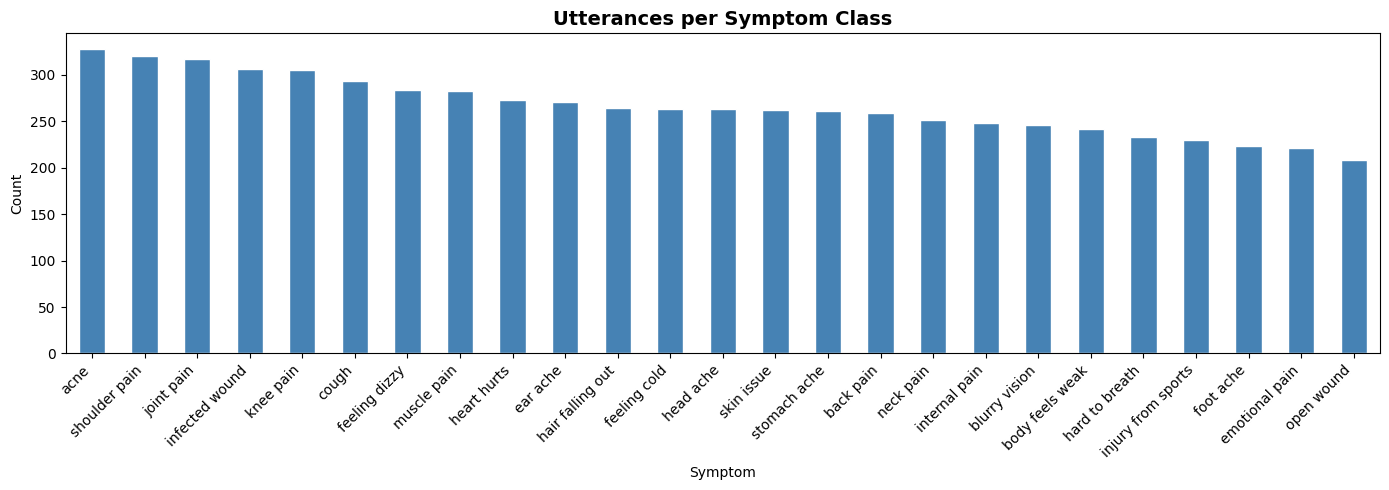


Total classes: 24
Min samples: 208 | Max: 328 | Mean: 266


In [12]:
# ── Class distribution ────────────────────────────────────────────────────────
counts = df['prompt'].value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Utterances per Symptom Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Symptom'); ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'\nTotal classes: {counts.nunique()}')
print(f'Min samples: {counts.min()} | Max: {counts.max()} | Mean: {counts.mean():.0f}')

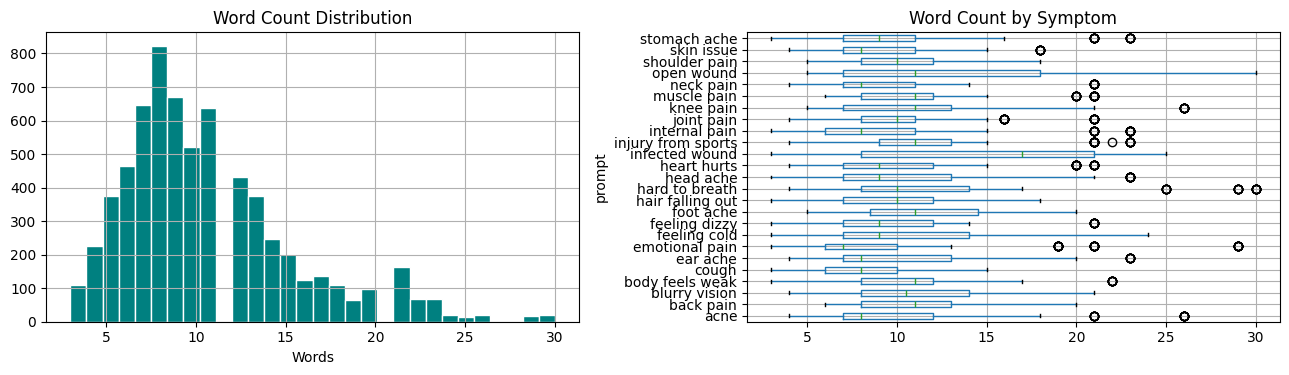

In [13]:
# ── Transcription length distribution ────────────────────────────────────────
df['word_count'] = df['phrase'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df['word_count'].hist(bins=30, ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Word Count Distribution'); axes[0].set_xlabel('Words')

df.boxplot(column='word_count', by='prompt', ax=axes[1], vert=False)
axes[1].set_title('Word Count by Symptom'); plt.suptitle('')
plt.tight_layout(); plt.show()

In [14]:
# ── Filter classes with too few samples (optional threshold) ──────────────────
MIN_SAMPLES = 30
valid_classes = counts[counts >= MIN_SAMPLES].index
df = df[df['prompt'].isin(valid_classes)]
print(f'Classes kept (≥{MIN_SAMPLES} samples): {len(valid_classes)}')
print(f'Total rows: {len(df)}')

Classes kept (≥30 samples): 25
Total rows: 6650


In [15]:
# ── Encode labels ─────────────────────────────────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['prompt'])
id2label = {i: c for i, c in enumerate(le.classes_)}
label2id = {c: i for i, c in id2label.items()}
NUM_CLASSES = len(le.classes_)
print(f'Label encoding complete. {NUM_CLASSES} classes.')
print(id2label)

Label encoding complete. 25 classes.
{0: 'acne', 1: 'back pain', 2: 'blurry vision', 3: 'body feels weak', 4: 'cough', 5: 'ear ache', 6: 'emotional pain', 7: 'feeling cold', 8: 'feeling dizzy', 9: 'foot ache', 10: 'hair falling out', 11: 'hard to breath', 12: 'head ache', 13: 'heart hurts', 14: 'infected wound', 15: 'injury from sports', 16: 'internal pain', 17: 'joint pain', 18: 'knee pain', 19: 'muscle pain', 20: 'neck pain', 21: 'open wound', 22: 'shoulder pain', 23: 'skin issue', 24: 'stomach ache'}


In [16]:
TARGET_SR  = 16_000   # Whisper & most ASR models expect 16 kHz
MIN_DUR    = 0.5      # seconds — drop clips shorter than this
MAX_DUR    = 15.0     # seconds — drop clips longer than this

def preprocess_audio(src_path: str, dst_path: str,
                     sr: int = TARGET_SR,
                     trim_silence: bool = True) -> dict:
    """Load, resample, trim silence, normalize, and save audio.
    Returns a dict with duration info or raises on error."""
    y, orig_sr = librosa.load(src_path, sr=None, mono=True)

    # Resample if needed
    if orig_sr != sr:
        y = librosa.resample(y, orig_sr=orig_sr, target_sr=sr)

    # Trim leading/trailing silence
    if trim_silence:
        y, _ = librosa.effects.trim(y, top_db=25)

    duration = len(y) / sr

    # Peak-normalize
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))

    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    sf.write(dst_path, y, sr)
    return {'duration': duration}

print('Preprocessing function defined.')

Preprocessing function defined.


In [17]:
# ── Scan disk and resolve bare filenames to full paths ───────────────────────
print("Scanning audio folders for .wav / .mp3 files...")

path_lookup = {}
for split in ['train', 'test', 'validate']:
    split_dir = AUDIO_ROOT / split
    if split_dir.exists():
        for f in split_dir.rglob('*.wav'):
            path_lookup[f.name] = f
        for f in split_dir.rglob('*.mp3'):
            path_lookup[f.name] = f
    else:
        print(f"  WARNING: {split_dir} not found")

print(f"Files found on disk: {len(path_lookup)}")
print("Sample filenames:", list(path_lookup.keys())[:5])

def resolve_path(raw):
    if pd.isna(raw):
        return None
    p = Path(str(raw))
    # Try as-is relative to AUDIO_ROOT
    full = AUDIO_ROOT / p
    if full.exists():
        return full
    # Try bare filename in lookup
    return path_lookup.get(p.name, None)

df['resolved_path'] = df['file_name'].apply(resolve_path)
missing = df['resolved_path'].isna().sum()
print(f"\nResolved: {len(df) - missing} / {len(df)}  ({missing} unresolved)")
df[['file_name', 'resolved_path', 'prompt', 'phrase']].head(5)

Scanning audio folders for .wav / .mp3 files...
Files found on disk: 6661
Sample filenames: ['1249120_44160489_107692984.wav', '1249120_44176037_39613511.wav', '1249120_44176037_85065458.wav', '1249120_44194084_23344116.wav', '1249120_44220382_48462181.wav']

Resolved: 6650 / 6650  (0 unresolved)


,file_name,resolved_path,prompt,phrase
0,1249120_43453425_58166571.wav,/kaggle/input/datasets/paultimothymooney/medic...,emotional pain,When I remember her I feel down
1,1249120_43719934_43347848.wav,/kaggle/input/datasets/paultimothymooney/medic...,hair falling out,When I carry heavy things I feel like breaking...
2,1249120_43719934_53187202.wav,/kaggle/input/datasets/paultimothymooney/medic...,heart hurts,there is too much pain when i move my arm
3,1249120_31349958_55816195.wav,/kaggle/input/datasets/paultimothymooney/medic...,infected wound,My son had his lip pierced and it is swollen a...
4,1249120_43719934_82524191.wav,/kaggle/input/datasets/paultimothymooney/medic...,infected wound,My muscles in my lower back are aching


In [18]:
# ── Run preprocessing ────────────────────────────────────────────────────────
# NOTE: Can take ~10-30 min on CPU. Skip if using transcriptions directly.

durations, bad_files = [], []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Preprocessing audio'):
    src_path = row['resolved_path']
    if src_path is None or str(src_path) == 'nan':
        bad_files.append(str(row.get('file_name', 'unknown')))
        durations.append(None)
        continue

    src_path = Path(src_path)
    rel      = src_path.relative_to(AUDIO_ROOT)
    dst_path = CLEAN_DIR / rel

    try:
        result = preprocess_audio(str(src_path), str(dst_path))
        durations.append(result['duration'])
    except Exception as e:
        bad_files.append(str(src_path))
        durations.append(None)

df['duration']   = durations
df['clean_path'] = [
    str(CLEAN_DIR / Path(row['resolved_path']).relative_to(AUDIO_ROOT))
    if (row['resolved_path'] is not None and str(row['resolved_path']) != 'nan') else None
    for _, row in df.iterrows()
]

print(f'Failed  : {len(bad_files)}')
if bad_files:
    print('  e.g.:', bad_files[:3])

df.dropna(subset=['duration'], inplace=True)
df = df[(df['duration'] >= MIN_DUR) & (df['duration'] <= MAX_DUR)]
print(f'Clean dataset size: {len(df)}')

Preprocessing audio:   0%|          | 0/6650 [00:00<?, ?it/s]

Failed  : 0
Clean dataset size: 6644


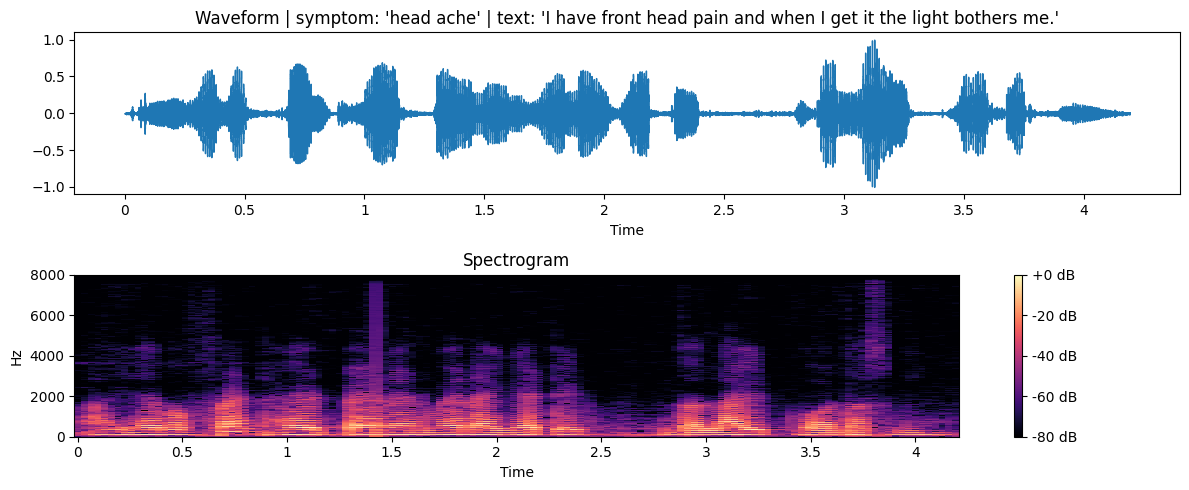

In [19]:
# ── Visualise a random sample ─────────────────────────────────────────────────
sample = df.sample(1).iloc[0]
audio_path = sample['clean_path']
y, sr = librosa.load(audio_path, sr=TARGET_SR)

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title(f"Waveform | symptom: '{sample['prompt']}' | text: '{sample['phrase']}'")

D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1])
axes[1].set_title('Spectrogram')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
plt.tight_layout(); plt.show()

****TRANSCIPTION****

In [20]:
def transcribe(audio_path: str) -> str:
    """Transcribe a single audio file using Whisper."""
    result = asr_model.transcribe(audio_path, language='en', fp16=(device == 'cuda'))
    return result['text'].strip()

# ── Transcribe all (can be slow on CPU; use GPU for speed) ────────────────────
# Comment out and use df['phrase'] directly if you prefer ground-truth text

whisper_texts = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Transcribing'):
    path = str(CLEAN_DIR / row['file_name'])
    try:
        text = transcribe(path)
    except Exception:
        text = row['phrase']   # fall back to ground-truth
    whisper_texts.append(text)

df['whisper_text'] = whisper_texts
df[['prompt', 'phrase', 'whisper_text']].head(5)

Transcribing:   0%|          | 0/6644 [00:00<?, ?it/s]

,prompt,phrase,whisper_text
0,emotional pain,When I remember her I feel down,When I remember her I feel down
1,hair falling out,When I carry heavy things I feel like breaking...,When I carry heavy things I feel like breaking...
2,heart hurts,there is too much pain when i move my arm,there is too much pain when i move my arm
3,infected wound,My son had his lip pierced and it is swollen a...,My son had his lip pierced and it is swollen a...
4,infected wound,My muscles in my lower back are aching,My muscles in my lower back are aching


In [21]:
# Use Whisper transcriptions for training; fall back to ground-truth if missing
TEXT_COL = 'whisper_text' if 'whisper_text' in df.columns else 'text'
print(f'Using text column: {TEXT_COL}')

# ── Train / val / test split ──────────────────────────────────────────────────
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Using text column: whisper_text
Train: 5315 | Val: 664 | Test: 665


In [22]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=128)

def make_hf_dataset(dataframe):
    ds = Dataset.from_dict({
        'text':  dataframe[TEXT_COL].tolist(),
        'label': dataframe['label'].tolist()
    })
    return ds.map(tokenize, batched=True)

train_ds = make_hf_dataset(train_df)
val_ds   = make_hf_dataset(val_df)
test_ds  = make_hf_dataset(test_df)
print('Datasets tokenized.')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/5315 [00:00<?, ? examples/s]

Map:   0%|          | 0/664 [00:00<?, ? examples/s]

Map:   0%|          | 0/665 [00:00<?, ? examples/s]

Datasets tokenized.


In [23]:
clf_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id
)
print(f'Model loaded: {MODEL_NAME} | {NUM_CLASSES} output classes')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased | 25 output classes


In [24]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir          = '/kaggle/working/checkpoints',
    num_train_epochs    = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate       = 2e-5,
    weight_decay        = 0.01,
    warmup_steps        = 0.1,
    eval_strategy = 'epoch',
    save_strategy       = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model  = 'accuracy',
    fp16                = (device == 'cuda'),
    logging_steps       = 50,
    report_to           = 'none',
    seed                = SEED,
)

trainer = Trainer(
    model           = clf_model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    processing_class       = tokenizer,
    data_collator   = DataCollatorWithPadding(tokenizer),
    compute_metrics = compute_metrics,
)

print('Trainer configured. Ready to train!')

Trainer configured. Ready to train!


In [25]:
# ── TRAIN ─────────────────────────────────────────────────────────────────────
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,2.191668,1.339141,0.891566
2,0.566700,0.252670,0.986446
3,0.120286,0.072020,0.998494
4,0.067419,0.044210,0.998494
5,0.060555,0.039248,0.998494


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=835, training_loss=0.7554380922260399, metrics={'train_runtime': 2049.6241, 'train_samples_per_second': 12.966, 'train_steps_per_second': 0.407, 'total_flos': 201503954176140.0, 'train_loss': 0.7554380922260399, 'epoch': 5.0})

In [26]:
# ── Save model & tokenizer ────────────────────────────────────────────────────
SAVE_DIR = '/kaggle/working/medical_symptom_classifier'
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Also save label mapping
import json
with open(f'{SAVE_DIR}/id2label.json', 'w') as f:
    json.dump(id2label, f, indent=2)
print(f'Model saved to {SAVE_DIR}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /kaggle/working/medical_symptom_classifier


In [27]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 3.6 MB/s eta 0:00:00a 0:00:01


In [31]:
import whisper
from transformers import pipeline as hf_pipeline

asr = whisper.load_model('base', device=device)
print("Whisper ready ")

clf = hf_pipeline(
    'text-classification',
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    top_k=3,
    device=0 if device == 'cuda' else -1
)
print("Classifier ready ")

Whisper ready 


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Classifier ready 


In [29]:
import random
import json
from pathlib import Path
from pydub import AudioSegment
from kaggle_secrets import UserSecretsClient

# ── LLM Client (Groq) ─────────────────────────────────────────
from groq import Groq
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("groq")
client = Groq(api_key=api_key)

# ── Helpers ────────────────────────────────────────────────
def convert_to_wav(path: str) -> str:
    out = Path('/kaggle/working') / (Path(path).stem + '_converted.wav')
    AudioSegment.from_file(path).export(str(out), format='wav')
    return str(out)

def diagnose(audio_path: str) -> dict:
    """Transcribe audio + classify top-3 symptoms."""
    path = str(Path(audio_path).expanduser())

    # Convert if needed
    ext = Path(path).suffix.lower()
    if ext in ['.ogg', '.mp3', '.m4a', '.flac']:
        path = convert_to_wav(path)

    # Step 1: Transcribe
    result = asr.transcribe(path, language='en', fp16=(device=='cuda'))
    text = result['text'].strip()

    # Step 2: Classify top-3 symptoms
    preds = clf(text)
# Flatten nested list: [[{...}]] → [{...}]
    if isinstance(preds[0], list):
        preds = preds[0]

    return {'transcription': text, 'predictions': preds}

def rich_diagnose(audio_path: str) -> dict:
    """ASR → classifier → LLM disease diagnosis."""
    result = diagnose(audio_path)
    text = result['transcription']
    top_preds = result['predictions']

    preds_str = "\n".join(f"{i+1}. {p['label']} ({p['score']*100:.1f}% confidence)"
                          for i, p in enumerate(top_preds))

    prompt = f"""
You are an experienced clinical diagnostician.

Patient said:
"{text}"

Detected symptoms:
{preds_str}

Return ONLY JSON:

{{
"disease_diagnosis":[
{{"disease":"name","likelihood":"high|medium|low","reasoning":"short reason"}},
{{"disease":"name","likelihood":"high|medium|low","reasoning":"short reason"}},
{{"disease":"name","likelihood":"high|medium|low","reasoning":"short reason"}}
],
"recommended_steps":["step1","step2","step3"],
"urgency":"routine|soon|urgent|emergency",
"disclaimer":"This is not a substitute for professional medical advice."
}}
"""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role":"user","content":prompt}],
            temperature=0.2
        )
        clean = response.choices[0].message.content.strip().replace("```json","").replace("```","").strip()
        report = json.loads(clean)
    except Exception as e:
        print(f" LLM call failed for {audio_path}: {e}")
        report = {
            "disease_diagnosis":[{"disease":"Unknown","likelihood":"low","reasoning":"Parsing failed"}],
            "recommended_steps":["Consult a doctor"],
            "urgency":"routine",
            "disclaimer":"This is not a substitute for professional medical advice."
        }

    return {"transcription": text, "predictions": top_preds, "report": report}

def print_rich_result(fname: str, result: dict):
    r = result['report']
    urgency_icon = {"routine":"🟢","soon":"🟡","urgent":"🟠","emergency":"🔴"}.get(r['urgency'], "⚪")
    print(f" File: {fname}\n Transcript: {result['transcription']}\n{urgency_icon} Urgency: {r['urgency'].upper()}\n")
    
    print(" Top-3 Symptoms:")
    for p in result['predictions']:
        bar = '█' * int(p['score']*20)
        print(f"   {p['label']:25s} {p['score']*100:5.1f}% {bar}")
    
    print("\n Disease Diagnosis:")
    for d in r['disease_diagnosis']:
        icon = {"high":"🔴","medium":"🟡","low":"🟢"}.get(d['likelihood'], "⚪")
        print(f"   {icon} {d['disease']:25s} [{d['likelihood'].upper()}] → {d['reasoning']}")
    
    print("\n Recommended Steps:")
    for i,s in enumerate(r['recommended_steps'],1):
        print(f"   {i}. {s}")
    
    print(f"\n {r['disclaimer']}")
    print("─"*55, "\n")

# ── Run pipeline on medical speech dataset ─────────────────
audio_files = list(AUDIO_ROOT.rglob('*.wav')) + list(AUDIO_ROOT.rglob('*.ogg'))
sample_files = random.sample(audio_files, min(5, len(audio_files)))

print(f"Found {len(audio_files)} total files, sampling {len(sample_files)}...\n")

for f in sample_files:
    try:
        result = rich_diagnose(str(f))
        print_rich_result(f.name, result)
    except Exception as e:
        print(f" Failed: {f.name} — {e}\n")

Found 6661 total files, sampling 5...

 File: 1249120_15004831_21045225.wav
 Transcript: I have tried to make massage on my foot but they still pain me.
🟢 Urgency: ROUTINE

 Top-3 Symptoms:
   foot ache                  95.2% ███████████████████
   joint pain                  0.5% 
   knee pain                   0.4% 

 Disease Diagnosis:
   🔴 Plantar Fasciitis         [HIGH] → Foot ache persistent after massage
   🟢 Arthritis                 [LOW] → Low joint pain confidence
   🟡 Overuse Injury            [MEDIUM] → Foot ache after self-massage attempt

 Recommended Steps:
   1. Rest and ice the foot
   2. Stretching exercises
   3. Consult a podiatrist

 This is not a substitute for professional medical advice.
─────────────────────────────────────────────────────── 

 File: 1249120_41841195_83381758.wav
 Transcript: I've always been very active, but now I just don't have the strength or energy to go for even a short walk.
🟡 Urgency: SOON

 Top-3 Symptoms:
   body feels weak         

In [30]:
from pathlib import Path
import random
# ── Pick 5 random WAV files from AUDIO_ROOT ────────────────────────────────
ex_audio=Path("/kaggle/input/datasets/manar9/audios")
wav_files = list(ex_audio.rglob("*.ogg"))
print(f"Total WAV files found: {len(wav_files)}")

sample_files = random.sample(wav_files, min(5, len(wav_files)))
print(f"\nTesting {len(sample_files)} random samples\n{'='*55}")

# ── Run Diagnosis ──────────────────────────────────────────────────────────
for f in sample_files:
    try:
        result = rich_diagnose(str(f))
        print_rich_result(f.name, result)
    except Exception as e:
        print(f"❌ Failed: {f.name} — {e}\n")

Total WAV files found: 3

Testing 3 random samples
 File: WhatsApp Ptt 2026-03-06 at 2.27.35 PM.ogg
 Transcript: My back hurts when I walk for too long.
🟢 Urgency: ROUTINE

 Top-3 Symptoms:
   back pain                  94.9% ██████████████████
   muscle pain                 0.7% 
   shoulder pain               0.3% 

 Disease Diagnosis:
   🔴 Lumbar Strain             [HIGH] → Back pain triggered by walking
   🟡 Herniated Disc            [MEDIUM] → Prolonged walking exacerbates back pain
   🟢 Degenerative Disc Disease [LOW] → Less likely without additional symptoms

 Recommended Steps:
   1. Schedule a doctor's appointment
   2. Apply heat or cold packs to the affected area
   3. Engage in gentle stretching exercises

 This is not a substitute for professional medical advice.
─────────────────────────────────────────────────────── 

 File: WhatsApp Ptt 2026-03-06 at 2.29.23 PM.ogg
 Transcript: My stomach hurts after every single meal.
🟡 Urgency: SOON

 Top-3 Symptoms:
   stomach ache  